In [1]:
#all student vle files
files = [f"studentVle_{i}.csv" for i in range(8)]
print(files)

['studentVle_0.csv', 'studentVle_1.csv', 'studentVle_2.csv', 'studentVle_3.csv', 'studentVle_4.csv', 'studentVle_5.csv', 'studentVle_6.csv', 'studentVle_7.csv']


In [2]:
#concatenating all files into one
import pandas as pd
student_vle = pd.concat(
    [pd.read_csv(f"/content/sample_data/{file}") for file in files],
    ignore_index=True
)

In [3]:
#checking the data
print(student_vle.head())

   Unnamed: 0 code_module code_presentation  id_student  id_site  date  \
0           0         AAA             2013J       28400   546652   -10   
1           1         AAA             2013J       28400   546652   -10   
2           2         AAA             2013J       28400   546652   -10   
3           3         AAA             2013J       28400   546614   -10   
4           4         AAA             2013J       28400   546714   -10   

   sum_click  
0          4  
1          1  
2          1  
3         11  
4          1  


In [4]:
#shape
print(student_vle.shape)

(10655280, 7)


In [5]:
#columns of vle
print(student_vle.columns)

Index(['Unnamed: 0', 'code_module', 'code_presentation', 'id_student',
       'id_site', 'date', 'sum_click'],
      dtype='object')


In [6]:
#dropping unnecessary columns
student_vle = student_vle.drop(columns=['Unnamed: 0'])

In [7]:
vle = pd.read_csv("/content/sample_data/vle.csv")

In [8]:
print(vle.columns)

Index(['id_site', 'code_module', 'code_presentation', 'activity_type',
       'week_from', 'week_to'],
      dtype='object')


In [9]:
merged_vle = student_vle.merge(
    vle,
    on='id_site',
    how='left'
)

In [10]:
#inserting week column
merged_vle['week'] = merged_vle['date'] // 7

In [11]:
#checking data
print(merged_vle.head())

  code_module_x code_presentation_x  id_student  id_site  date  sum_click  \
0           AAA               2013J       28400   546652   -10          4   
1           AAA               2013J       28400   546652   -10          1   
2           AAA               2013J       28400   546652   -10          1   
3           AAA               2013J       28400   546614   -10         11   
4           AAA               2013J       28400   546714   -10          1   

  code_module_y code_presentation_y activity_type  week_from  week_to  week  
0           AAA               2013J       forumng        NaN      NaN    -2  
1           AAA               2013J       forumng        NaN      NaN    -2  
2           AAA               2013J       forumng        NaN      NaN    -2  
3           AAA               2013J      homepage        NaN      NaN    -2  
4           AAA               2013J     oucontent        NaN      NaN    -2  


In [12]:
#engineering frequency feature
frequency = merged_vle.groupby(
    ['id_student', 'week']
)['sum_click'].sum().reset_index()

In [13]:
print(frequency.head())

   id_student  week  sum_click
0        6516    -4        110
1        6516    -3         48
2        6516    -2          2
3        6516    -1         96
4        6516     0        229


In [14]:
#engineering diversity feature
diversity = merged_vle.groupby(
    ['id_student', 'week']
)['activity_type'].nunique().reset_index()

In [15]:
print(diversity.head())

   id_student  week  activity_type
0        6516    -4              5
1        6516    -3              6
2        6516    -2              2
3        6516    -1              6
4        6516     0              6


In [36]:
#engineering recency feature
recency = merged_vle.groupby(
    ['id_student', 'week']
)['date'].max().reset_index()

recency = recency.rename(
    columns={'date': 'last_activity_date'}
)

recency['week_end'] = 7 * (recency['week'] + 1) - 1

recency['days_inactive'] = (
    recency['week_end'] - recency['last_activity_date']
).clip(lower=0)

recency['recency_score'] = np.exp(
    -recency['days_inactive'] / 7
)

In [37]:
print(recency.head())

   id_student  week  last_activity_date  week_end  days_inactive  \
0        6516    -4                 -22       -22              0   
1        6516    -3                 -17       -15              2   
2        6516    -2                 -12        -8              4   
3        6516    -1                  -1        -1              0   
4        6516     0                   6         6              0   

   recency_score  
0       1.000000  
1       0.751477  
2       0.564718  
3       1.000000  
4       1.000000  


In [21]:
import pandas as pd
student_assessment = pd.read_csv("/content/sample_data/studentAssessment.csv")

In [22]:
print(student_assessment.head())
print(student_assessment.columns)
print(student_assessment.shape)

   id_assessment  id_student  date_submitted  is_banked  score
0           1752       11391              18          0   78.0
1           1752       28400              22          0   70.0
2           1752       31604              17          0   72.0
3           1752       32885              26          0   69.0
4           1752       38053              19          0   79.0
Index(['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score'], dtype='object')
(173912, 5)


In [23]:
student_assessment = student_assessment.dropna(subset=['score'])

In [24]:
student_assessment.describe()

,id_assessment,id_student,date_submitted,is_banked,score
count,173739.000000,1.737390e+05,173739.000000,173739.000000,173739.000000
mean,26555.615826,7.052474e+05,116.020226,0.010982,75.799573
std,8829.999907,5.524822e+05,71.479612,0.104218,18.798107
min,1752.000000,6.516000e+03,-11.000000,0.000000,0.000000
25%,15022.000000,5.044660e+05,51.000000,0.000000,65.000000
50%,25359.000000,5.852220e+05,116.000000,0.000000,80.000000
75%,34883.000000,6.345000e+05,173.000000,0.000000,90.000000
max,37443.000000,2.698588e+06,608.000000,1.000000,100.000000


In [25]:
student_assessment['id_student'].nunique()

23351

In [26]:
student_assessment['week'] = student_assessment['date_submitted'] // 7

In [27]:
#Weekly number of submissions per student
weekly_submission = student_assessment.groupby(
    ['id_student', 'week']
).agg(
    submission_count=('id_assessment', 'count'),
    avg_score=('score', 'mean'),
    min_score=('score', 'min'),
    max_score=('score', 'max')
).reset_index()

print(weekly_submission.head())

   id_student  week  submission_count  avg_score  min_score  max_score
0        6516     2                 1       60.0       60.0       60.0
1        6516     7                 1       48.0       48.0       48.0
2        6516    16                 1       63.0       63.0       63.0
3        6516    23                 1       61.0       61.0       61.0
4        6516    30                 1       77.0       77.0       77.0


In [28]:
#Score consistency per student
assessment_consistency = student_assessment.groupby(
    'id_student'
).agg(
    total_submissions=('id_assessment', 'count'),
    avg_assessment_score=('score', 'mean'),
    score_std=('score', 'std')
).reset_index()

# If a student has only one assessment, std becomes NaN
assessment_consistency['score_std'] = assessment_consistency['score_std'].fillna(0)

In [29]:
#assessment consistency
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

assessment_consistency['score_std_norm'] = scaler.fit_transform(
    assessment_consistency[['score_std']]
)
assessment_consistency['assessment_consistency_score'] = (
    1 - assessment_consistency['score_std_norm']
)

print(assessment_consistency.head())

   id_student  total_submissions  avg_assessment_score  score_std  \
0        6516                  5             61.800000  10.329569   
1        8462                  7             87.000000   4.472136   
2       11391                  5             82.000000   3.082207   
3       23629                  4             82.500000  20.273135   
4       23698                  9             74.444444  13.258121   

   score_std_norm  assessment_consistency_score  
0        0.147558                      0.852442  
1        0.063884                      0.936116  
2        0.044029                      0.955971  
3        0.289601                      0.710399  
4        0.189392                      0.810608  


In [33]:
diversity = diversity.rename(columns={'activity_type': 'activity_diversity'})
features = frequency.merge(
    diversity,
    on=['id_student', 'week'],
    how='left'
)
features = features.merge(
    recency[['id_student', 'week', 'recency_score']],
    on=['id_student', 'week'],
    how='left'
)

features = features.fillna(0)
print(features.head())
print(features.columns)

   id_student  week  sum_click  activity_diversity  recency_score
0        6516    -4        110                   5       0.866878
1        6516    -3         48                   6       0.651439
2        6516    -2          2                   2       0.489542
3        6516    -1         96                   6       0.866878
4        6516     0        229                   6       0.866878
Index(['id_student', 'week', 'sum_click', 'activity_diversity',
       'recency_score'],
      dtype='object')


In [34]:
features = features.merge(
    weekly_submission,
    on=['id_student', 'week'],
    how='left'
)
features = features.merge(
    assessment_consistency[
        ['id_student', 'total_submissions', 'avg_assessment_score', 'assessment_consistency_score']
    ],
    on='id_student',
    how='left'
)

features['submission_count'] = features['submission_count'].fillna(0)
features['avg_score'] = features['avg_score'].fillna(0)
features['min_score'] = features['min_score'].fillna(0)
features['max_score'] = features['max_score'].fillna(0)

print(features.head())

   id_student  week  sum_click  activity_diversity  recency_score  \
0        6516    -4        110                   5       0.866878   
1        6516    -3         48                   6       0.651439   
2        6516    -2          2                   2       0.489542   
3        6516    -1         96                   6       0.866878   
4        6516     0        229                   6       0.866878   

   submission_count  avg_score  min_score  max_score  total_submissions  \
0               0.0        0.0        0.0        0.0                5.0   
1               0.0        0.0        0.0        0.0                5.0   
2               0.0        0.0        0.0        0.0                5.0   
3               0.0        0.0        0.0        0.0                5.0   
4               0.0        0.0        0.0        0.0                5.0   

   avg_assessment_score  assessment_consistency_score  
0                  61.8                      0.852442  
1                  61.

In [35]:
#trend slope
import numpy as np
frequency = frequency.sort_values(['id_student', 'week'])
def rolling_slope(group, window=3):
    slopes = []
    clicks = group['sum_click'].values

    for i in range(len(clicks)):
        if i < window - 1:
            slopes.append(0)
        else:
            y = clicks[i-window+1:i+1]
            x = np.arange(window)
            slope = np.polyfit(x, y, 1)[0]
            slopes.append(slope)

    group['weekly_trend_slope'] = slopes
    return group
trend = frequency.groupby('id_student', group_keys=False).apply(rolling_slope)
trend.head()

/tmp/ipykernel_20111/1492694478.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trend = frequency.groupby('id_student', group_keys=False).apply(rolling_slope)


,id_student,week,sum_click,weekly_trend_slope
0,6516,-4,110,0.0
1,6516,-3,48,0.0
2,6516,-2,2,-54.0
3,6516,-1,96,24.0
4,6516,0,229,113.5


In [43]:
features = features.merge(
    trend[['id_student', 'week', 'weekly_trend_slope']],
    on=['id_student', 'week'],
    how='left'
)


In [44]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

features[['clicks_norm',
          'diversity_norm',
          'trend_norm',
          'submission_norm',
          'recency_norm',
           'assessment_consistency_norm']] = scaler.fit_transform(
    features[['sum_click',
              'activity_diversity',
              'weekly_trend_slope',
              'submission_count',
              'recency_score',
              'assessment_consistency_score']]
)

In [45]:
#engagement score
features['engagement_score'] = (
    0.25 * features['clicks_norm'] +
    0.15 * features['diversity_norm'] +
    0.20 * features['recency_norm'] +
    0.15 * features['trend_norm'] +
    0.15 * features['submission_norm'] +
    0.10 * features['assessment_consistency_norm']
) * 100

features[['id_student', 'week', 'engagement_score']].head()

,id_student,week,engagement_score
0,6516,-4,41.047507
1,6516,-3,33.345012
2,6516,-2,21.960122
3,6516,-1,42.203019
4,6516,0,42.870876


In [46]:
summary = features.groupby('id_student').agg(
    first_score=('engagement_score', 'first'),
    last_score=('engagement_score', 'last'),
    avg_score=('engagement_score', 'mean'),
    std_score=('engagement_score', 'std')
).reset_index()

summary['score_change'] = summary['last_score'] - summary['first_score']

In [47]:
#steady student
steady_student = summary.sort_values(
    ['avg_score', 'std_score'],
    ascending=[False, True]
).iloc[0]['id_student']

steady_student

np.float64(537811.0)

In [48]:
student_data = features[
    features['id_student'] == steady_student
].sort_values('week')

student_data[['week', 'engagement_score']]

,week,engagement_score
182794,-3,46.357605
182795,-2,51.444608
182796,-1,48.370669
182797,0,57.332512
182798,1,51.643225
182799,2,51.306769
182800,3,52.569997
182801,4,52.912135
182802,5,52.489913
182803,6,54.629058


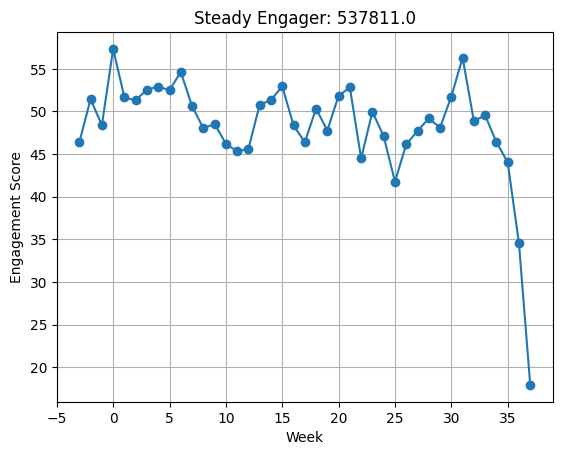

In [49]:
import matplotlib.pyplot as plt

plt.plot(
    student_data['week'],
    student_data['engagement_score'],
    marker='o'
)

plt.title(f"Steady Engager: {steady_student}")
plt.xlabel("Week")
plt.ylabel("Engagement Score")
plt.grid(True)
plt.show()

In [50]:
#early dropout student
early_dropout_student = summary.sort_values(
    'score_change'
).iloc[0]['id_student']

early_dropout_student

np.float64(654597.0)

In [51]:
student_data = features[
    features['id_student'] == early_dropout_student
].sort_values('week')

student_data[['week', 'engagement_score']]

,week,engagement_score
459879,0,48.292648
459880,1,39.109078
459881,2,39.201613
459882,3,42.367928
459883,4,33.908134
459884,5,40.247186
459885,6,41.431275
459886,7,41.371125
459887,8,32.951503
459888,9,41.311866


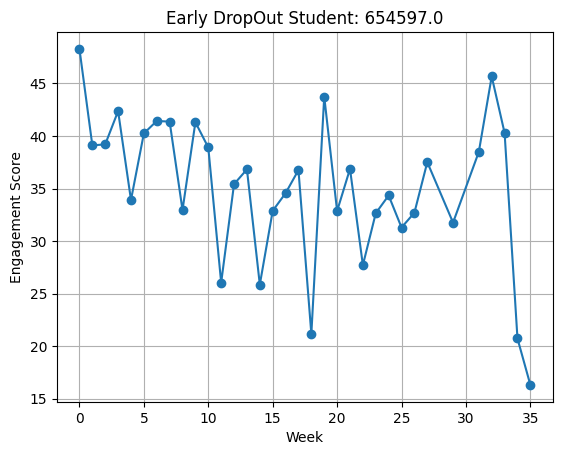

In [52]:
import matplotlib.pyplot as plt

plt.plot(
    student_data['week'],
    student_data['engagement_score'],
    marker='o'
)

plt.title(f"Early DropOut Student: {early_dropout_student}")
plt.xlabel("Week")
plt.ylabel("Engagement Score")
plt.grid(True)
plt.show()

In [53]:
#late recoverer student
late_recoverer_student = summary.sort_values(
    'score_change',
    ascending=False
).iloc[0]['id_student']

late_recoverer_student

np.float64(555349.0)

In [54]:
student_data = features[
    features['id_student'] == late_recoverer_student
].sort_values('week')

student_data[['week', 'engagement_score']]

,week,engagement_score
215711,-2,18.610016
215712,-1,32.365576
215713,0,33.614949
215714,1,31.299749
215715,2,44.727446
215716,3,34.057705
215717,4,25.324585
215718,5,23.602953
215719,6,37.850695
215720,7,32.918932


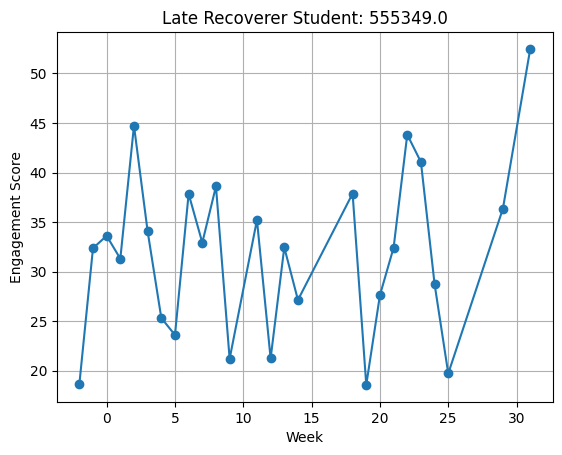

In [55]:
import matplotlib.pyplot as plt

plt.plot(
    student_data['week'],
    student_data['engagement_score'],
    marker='o'
)

plt.title(f"Late Recoverer Student: {late_recoverer_student}")
plt.xlabel("Week")
plt.ylabel("Engagement Score")
plt.grid(True)
plt.show()

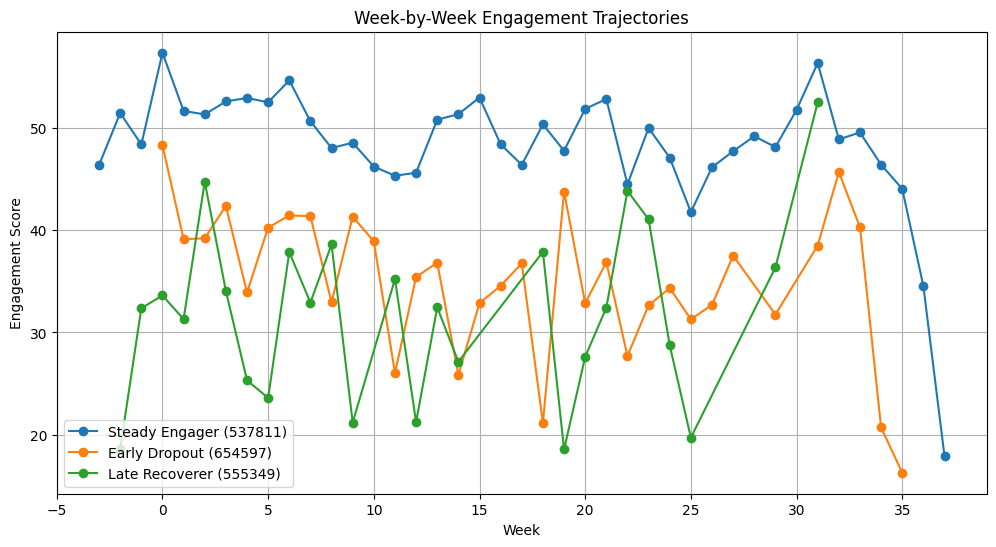

In [56]:
import matplotlib.pyplot as plt

selected_students = {
    'Steady Engager': steady_student,
    'Early Dropout': early_dropout_student,
    'Late Recoverer': late_recoverer_student
}

plt.figure(figsize=(12, 6))

for label, student_id in selected_students.items():
    student_data = features[features['id_student'] == student_id].sort_values('week')
    plt.plot(
        student_data['week'],
        student_data['engagement_score'],
        marker='o',
        label=f'{label} ({int(student_id)})'
    )

plt.title('Week-by-Week Engagement Trajectories')
plt.xlabel('Week')
plt.ylabel('Engagement Score')
plt.legend()
plt.grid(True)
plt.show()

In [57]:
student_info = pd.read_csv("/content/sample_data/studentInfo.csv")

feature_outcome = features.merge(
    student_info[['id_student', 'final_result']],
    on='id_student',
    how='left'
)

In [58]:
#rationale table
rationale_table = feature_outcome.groupby('final_result').agg(
    avg_clicks=('sum_click', 'mean'),
    avg_diversity=('activity_diversity', 'mean'),
    avg_recency=('recency_score', 'mean'),
    avg_submissions=('submission_count', 'mean'),
    avg_trend=('weekly_trend_slope', 'mean'),
    avg_consistency=('assessment_consistency_score', 'mean'),
    avg_engagement_score=('engagement_score', 'mean')
).reset_index()

rationale_table

,final_result,avg_clicks,avg_diversity,avg_recency,avg_submissions,avg_trend,avg_consistency,avg_engagement_score
0,Distinction,93.784733,4.513468,0.740147,0.290633,-0.978570,0.873949,35.873143
1,Fail,52.847172,3.902281,0.689361,0.279337,-0.328895,0.778628,32.110915
2,Pass,71.912768,4.199778,0.717075,0.296353,-0.272645,0.813558,33.912189
3,Withdrawn,62.780241,4.181133,0.704851,0.238594,-0.663006,0.808130,33.475225


In [59]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, StackingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [60]:
#data uptil week 6
week6_features = features[features['week'] <= 6].copy()

model_data = week6_features.groupby('id_student').agg(
    avg_clicks=('sum_click', 'mean'),
    total_clicks=('sum_click', 'sum'),
    avg_diversity=('activity_diversity', 'mean'),
    avg_recency=('recency_score', 'mean'),
    avg_trend=('weekly_trend_slope', 'mean'),
    min_trend=('weekly_trend_slope', 'min'),
    total_submissions_week6=('submission_count', 'sum'),
    avg_consistency=('assessment_consistency_score', 'mean'),
    avg_engagement_score=('engagement_score', 'mean'),
    min_engagement_score=('engagement_score', 'min')
).reset_index()

In [61]:
#including final result into data
student_info['target'] = student_info['final_result'].map({
    'Withdrawn': 1,
    'Fail': 1,
    'Pass': 0,
    'Distinction': 0
})
model_data = model_data.merge(
    student_info[['id_student', 'target', 'final_result']],
    on='id_student',
    how='inner'
)
model_data = model_data.dropna()

In [62]:
#train-test-split
X = model_data.drop(columns=['id_student', 'target', 'final_result'])
y = model_data['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [63]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [64]:
#smote
smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_balanced).value_counts())

Before SMOTE:
target
0    11482
1     8456
Name: count, dtype: int64

After SMOTE:
target
0    11482
1    11482
Name: count, dtype: int64


In [65]:
#ml model
base_learners = [
    ('rf', RandomForestClassifier(
        n_estimators=120,
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features='sqrt',
        bootstrap=True,
        class_weight='balanced_subsample',
        random_state=42
    )),

    ('xgb', XGBClassifier(
        eval_metric='logloss',
        n_estimators=100,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.6,
        colsample_bytree=0.6,
        scale_pos_weight=2,
        reg_lambda=10.0,
        reg_alpha=2.0,
        gamma=10.0,
        random_state=42
    )),

    ('lgb', LGBMClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.7,
        colsample_bytree=0.7,
        class_weight='balanced',
        reg_lambda=5.0,
        reg_alpha=1.0,
        random_state=42
    ))
]

meta_learner = ExtraTreesClassifier(
    n_estimators=100,
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

stacking_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    passthrough=True,
    cv=5,
    n_jobs=-1
)

stacking_model.fit(X_train_balanced, y_train_balanced)

StackingClassifier(cv=5,
                   estimators=[('rf',
                                RandomForestClassifier(class_weight='balanced_subsample',
                                                       max_depth=5,
                                                       min_samples_leaf=5,
                                                       min_samples_split=10,
                                                       n_estimators=120,
                                                       random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=0.6, device=None,
                                              early_stopping_rounds...
                                              num_parallel_tree=None, ...)),
                               ('lgb',
                                LGBMClassifier(class_weight='balanced',
                                               colsample_bytree=0.7,
                                               learning_rate=0.05, max_depth=5,
                                               random_state=42, reg_alpha=1.0,
                                               reg_lambda=5.0,
                                               subsample=0.7))],
                   final_estimator=ExtraTreesClassifier(class_weight='balanced',
                                                        max_depth=6,
                                                        min_samples_leaf=5,
                                                        min_samples_split=10,
                                                        n_jobs=-1,
                                                        random_state=42),
                   n_jobs=-1, passthrough=True)

In [66]:
y_proba = stacking_model.predict_proba(X_test_scaled)[:, 1]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [67]:
#threshold tuning
thresholds = np.linspace(0.1, 0.9, 81)

threshold_results = []

for thresh in thresholds:
    y_pred_temp = (y_proba >= thresh).astype(int)

    precision = precision_score(y_test, y_pred_temp, zero_division=0)
    recall = recall_score(y_test, y_pred_temp, zero_division=0)
    f1 = f1_score(y_test, y_pred_temp, zero_division=0)

    threshold_results.append({
        'threshold': thresh,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results.sort_values(
    ['recall', 'f1'],
    ascending=[False, False]
).head(10)

,threshold,precision,recall,f1
4,0.14,0.424293,1.000000,0.595794
0,0.10,0.424165,1.000000,0.595668
1,0.11,0.424165,1.000000,0.595668
2,0.12,0.424165,1.000000,0.595668
3,0.13,0.424165,1.000000,0.595668
5,0.15,0.424653,0.999645,0.596087
6,0.16,0.425057,0.998936,0.596357
7,0.17,0.425847,0.998226,0.597009
8,0.18,0.426016,0.996807,0.596920
9,0.19,0.426573,0.995388,0.597212


In [68]:
# best threshold for optimised recall
candidate_thresholds = threshold_results[threshold_results['recall'] >= 0.80]

if len(candidate_thresholds) > 0:
    best_row = candidate_thresholds.sort_values('f1', ascending=False).iloc[0]
else:
    best_row = threshold_results.sort_values('recall', ascending=False).iloc[0]

best_thresh = best_row['threshold']

print("Selected Threshold:", best_thresh)
print(best_row)

Selected Threshold: 0.41000000000000003
threshold    0.410000
precision    0.530392
recall       0.801703
f1           0.638418
Name: 31, dtype: float64


In [69]:
#classification report
y_final = (y_proba >= best_thresh).astype(int)

print(f"Selected Threshold: {best_thresh:.3f}")
print(f"Accuracy: {accuracy_score(y_test, y_final) * 100:.2f}%")
print(f"Precision: {precision_score(y_test, y_final, zero_division=0):.3f}")
print(f"Recall: {recall_score(y_test, y_final, zero_division=0):.3f}")
print(f"F1-score: {f1_score(y_test, y_final, zero_division=0):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_final, zero_division=0))

Selected Threshold: 0.410
Accuracy: 61.48%
Precision: 0.530
Recall: 0.802
F1-score: 0.638
ROC-AUC: 0.746

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.48      0.59      3827
           1       0.53      0.80      0.64      2819

    accuracy                           0.61      6646
   macro avg       0.65      0.64      0.61      6646
weighted avg       0.67      0.61      0.61      6646



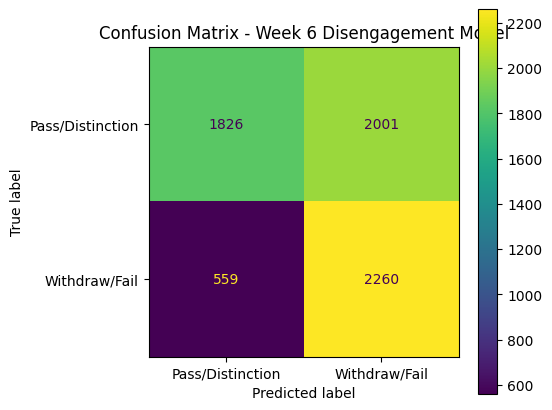

In [70]:
#confusion matrix
cm = confusion_matrix(y_test, y_final)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Pass/Distinction', 'Withdraw/Fail']
)

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, values_format='d')
plt.title("Confusion Matrix - Week 6 Disengagement Model")
plt.show()

In [71]:
#calibration
calibration_df = pd.DataFrame({
    'predicted_risk': y_proba,
    'actual': y_test.values
})

calibration_df['risk_bucket'] = pd.cut(
    calibration_df['predicted_risk'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=['0-20%', '20-40%', '40-60%', '60-80%', '80-100%']
)

calibration_table = calibration_df.groupby('risk_bucket').agg(
    avg_predicted_risk=('predicted_risk', 'mean'),
    actual_disengagement_rate=('actual', 'mean'),
    student_count=('actual', 'count')
).reset_index()

calibration_table

/tmp/ipykernel_20111/1720661965.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calibration_table = calibration_df.groupby('risk_bucket').agg(


,risk_bucket,avg_predicted_risk,actual_disengagement_rate,student_count
0,0-20%,0.177815,0.186916,107
1,20-40%,0.320832,0.233398,2048
2,40-60%,0.474364,0.393504,3202
3,60-80%,0.656230,0.672489,687
4,80-100%,0.956293,0.995017,602


In [72]:
#top 3 features
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    stacking_model,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='recall'
)

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': perm_importance.importances_mean
}).sort_values('importance', ascending=False)

top_3_features = feature_importance.head(3)

top_3_features

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

,feature,importance
7,avg_consistency,0.181270
6,total_submissions_week6,0.005782
3,avg_recency,0.004292


In [73]:
#alert
alert_data = model_data.loc[X_test.index].copy()

alert_data['predicted_risk'] = y_proba
alert_data['predicted_label'] = y_final

alert_data['alert_status'] = np.where(
    alert_data['predicted_risk'] >= best_thresh,
    'ALERT',
    'NO ALERT'
)

alerts = alert_data[alert_data['alert_status'] == 'ALERT'].copy()

alerts[['id_student', 'predicted_risk', 'alert_status', 'final_result']].head(20)

,id_student,predicted_risk,alert_status,final_result
8168,523061,0.484832,ALERT,Pass
9789,546074,0.434672,ALERT,Pass
1584,199361,0.458024,ALERT,Fail
7947,518951,0.638794,ALERT,Fail
13271,577735,0.412548,ALERT,Pass
9725,545297,0.970072,ALERT,Fail
5673,465843,0.485747,ALERT,Fail
19842,625740,0.526940,ALERT,Pass
2897,316772,0.498272,ALERT,Withdrawn
24288,678612,0.965473,ALERT,Fail


In [74]:
#advisor notification
def advisor_notification(row):
    return f"""
STUDENT RISK ALERT

Student ID: {int(row['id_student'])}
Predicted Disengagement Risk: {row['predicted_risk']:.1%}
Alert Threshold: {best_thresh:.1%}
Status: HIGH RISK

Reason:
- Early engagement score: {row['avg_engagement_score']:.2f}
- Minimum engagement score by Week 6: {row['min_engagement_score']:.2f}
- Average recency score: {row['avg_recency']:.2f}
- Total submissions by Week 6: {row['total_submissions_week6']}

Recommended Advisor Action:
Contact the student within 48 hours, check whether they are facing academic or personal barriers, and recommend tutoring, mentoring, or course support.
"""

print(advisor_notification(alerts.iloc[0]))


STUDENT RISK ALERT

Student ID: 523061
Predicted Disengagement Risk: 48.5%
Alert Threshold: 41.0%
Status: HIGH RISK

Reason:
- Early engagement score: 29.96
- Minimum engagement score by Week 6: 20.03
- Average recency score: 0.65
- Total submissions by Week 6: 2.0

Recommended Advisor Action:
Contact the student within 48 hours, check whether they are facing academic or personal barriers, and recommend tutoring, mentoring, or course support.



In [75]:
#course recommendation
courses = pd.read_csv("/content/sample_data/courses.csv")

In [77]:
#course wise student profile
student_course_features = features.merge(
    student_info[['id_student', 'code_module', 'code_presentation', 'final_result']],
    on='id_student',
    how='left'
)

student_course_profile = student_course_features.groupby(
    ['id_student', 'code_module']
).agg(
    avg_engagement_score=('engagement_score', 'mean'),
    avg_clicks=('sum_click', 'mean'),
    avg_diversity=('activity_diversity', 'mean'),
    avg_recency=('recency_score', 'mean'),
    avg_submissions=('submission_count', 'mean'),
    final_result=('final_result', 'first')
).reset_index()

student_course_profile['success'] = student_course_profile['final_result'].isin(
    ['Pass', 'Distinction']
).astype(int)

student_course_profile.head()

,id_student,code_module,avg_engagement_score,avg_clicks,avg_diversity,avg_recency,avg_submissions,final_result,success
0,6516,AAA,36.458566,71.564103,4.307692,0.772375,0.128205,Pass,1
1,8462,DDD,36.029820,38.588235,4.647059,0.726552,0.411765,Withdrawn,0
2,11391,AAA,29.540997,34.592593,2.851852,0.619825,0.111111,Pass,1
3,23629,BBB,22.638411,14.636364,2.181818,0.525365,0.272727,Fail,0
4,23698,CCC,32.743251,33.703704,3.703704,0.707296,0.259259,Pass,1


In [78]:
#course profile
course_profiles = student_course_profile.groupby('code_module').agg(
    course_avg_engagement=('avg_engagement_score', 'mean'),
    course_avg_clicks=('avg_clicks', 'mean'),
    course_avg_diversity=('avg_diversity', 'mean'),
    course_avg_recency=('avg_recency', 'mean'),
    course_success_rate=('success', 'mean'),
    popularity=('id_student', 'count')
).reset_index()

course_profiles

,code_module,course_avg_engagement,course_avg_clicks,course_avg_diversity,course_avg_recency,course_success_rate,popularity
0,AAA,33.734757,56.038363,3.677572,0.709687,0.729345,702
1,BBB,30.681040,33.903190,3.281041,0.672915,0.566482,6498
2,CCC,33.655874,70.616546,4.118468,0.703434,0.405129,4016
3,DDD,33.799892,42.146841,4.206607,0.704489,0.462261,5432
4,EEE,33.319532,66.454877,3.888952,0.697151,0.614253,2652
5,FFF,35.083967,92.126807,4.655508,0.707702,0.522154,6816
6,GGG,29.625596,28.334091,3.144524,0.646830,0.639254,2359


In [79]:
student_profiles = student_course_profile.groupby('id_student').agg(
    student_avg_engagement=('avg_engagement_score', 'mean'),
    student_avg_clicks=('avg_clicks', 'mean'),
    student_avg_diversity=('avg_diversity', 'mean'),
    student_avg_recency=('avg_recency', 'mean'),
    student_success_rate=('success', 'mean')
).reset_index()

student_profiles.head()

,id_student,student_avg_engagement,student_avg_clicks,student_avg_diversity,student_avg_recency,student_success_rate
0,6516,36.458566,71.564103,4.307692,0.772375,1.0
1,8462,36.029820,38.588235,4.647059,0.726552,0.0
2,11391,29.540997,34.592593,2.851852,0.619825,1.0
3,23629,22.638411,14.636364,2.181818,0.525365,0.0
4,23698,32.743251,33.703704,3.703704,0.707296,1.0


In [80]:
course_feature_cols = [
    'course_avg_engagement',
    'course_avg_clicks',
    'course_avg_diversity',
    'course_avg_recency',
    'course_success_rate'
]

student_feature_cols = [
    'student_avg_engagement',
    'student_avg_clicks',
    'student_avg_diversity',
    'student_avg_recency',
    'student_success_rate'
]

scaler = MinMaxScaler()

course_matrix = scaler.fit_transform(course_profiles[course_feature_cols])

In [83]:
#similarity between student and course profiles
from sklearn.metrics.pairwise import cosine_similarity

def content_based_recommend(student_id, top_k=3):
    student_row = student_profiles[student_profiles['id_student'] == student_id]
    # Cold-start fallback
    if student_row.empty:
        return cold_start_recommend(top_k)
    column_mapping = {
        'student_avg_engagement': 'course_avg_engagement',
        'student_avg_clicks': 'course_avg_clicks',
        'student_avg_diversity': 'course_avg_diversity',
        'student_avg_recency': 'course_avg_recency',
        'student_success_rate': 'course_success_rate'
    }
    student_vector = scaler.transform(student_row[student_feature_cols].rename(columns=column_mapping))
    similarities = cosine_similarity(student_vector, course_matrix)[0]
    recs = course_profiles.copy()
    recs['similarity_score'] = similarities
    taken_courses = student_course_profile[
        student_course_profile['id_student'] == student_id
    ]['code_module'].unique()
    recs = recs[~recs['code_module'].isin(taken_courses)]
    return recs.sort_values(
        'similarity_score',
        ascending=False
    ).head(top_k)[
        ['code_module', 'similarity_score', 'course_success_rate', 'popularity']
    ]

In [84]:
#cold start
cold_start_table = course_profiles.copy()
cold_start_table['popularity_norm'] = (
    cold_start_table['popularity'] / cold_start_table['popularity'].max()
)
cold_start_table['engagement_norm'] = (
    cold_start_table['course_avg_engagement'] / cold_start_table['course_avg_engagement'].max()
)
cold_start_table['cold_start_score'] = (
    0.5 * cold_start_table['course_success_rate'] +
    0.3 * cold_start_table['popularity_norm'] +
    0.2 * cold_start_table['engagement_norm']
)
def cold_start_recommend(top_k=3):
    return cold_start_table.sort_values(
        'cold_start_score',
        ascending=False
    ).head(top_k)[
        ['code_module', 'cold_start_score', 'course_success_rate', 'popularity']
    ]

In [ ]:
#interaction between student and courses
student_course_profile['rating'] = (
    0.7 * student_course_profile['avg_engagement_score'] +
    30 * student_course_profile['success']
)

interaction_matrix = student_course_profile.pivot_table(
    index='id_student',
    columns='code_module',
    values='rating',
    fill_value=0
)
student_similarity = cosine_similarity(interaction_matrix)
student_similarity_df = pd.DataFrame(
    student_similarity,
    index=interaction_matrix.index,
    columns=interaction_matrix.index
)

interaction_matrix.head()

code_module,AAA,BBB,CCC,DDD,EEE,FFF,GGG
id_student,,,,,,,
6516,55.520996,0.000000,0.000000,0.000000,0.0,0.0,0.0
8462,0.000000,0.000000,0.000000,25.220874,0.0,0.0,0.0
11391,50.678698,0.000000,0.000000,0.000000,0.0,0.0,0.0
23629,0.000000,15.846888,0.000000,0.000000,0.0,0.0,0.0
23698,0.000000,0.000000,52.920276,0.000000,0.0,0.0,0.0


In [85]:
#similarity between students
student_course_profile['rating'] = (
    0.7 * student_course_profile['avg_engagement_score'] +
    30 * student_course_profile['success']
)

interaction_matrix = student_course_profile.pivot_table(
    index='id_student',
    columns='code_module',
    values='rating',
    fill_value=0
)
student_similarity = cosine_similarity(interaction_matrix)
student_similarity_df = pd.DataFrame(
    student_similarity,
    index=interaction_matrix.index,
    columns=interaction_matrix.index
)
student_similarity_df.head()

id_student,6516,8462,11391,23629,23698,23798,24186,24213,24391,24734,...,2697181,2697630,2697885,2697921,2698125,2698251,2698257,2698535,2698577,2698588
id_student,,,,,,,,,,,,,,,,,,,,,
6516,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,1.0,0.0000,0.0,0.0
8462,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.707107,0.0,1.0,0.0,0.0000,0.0,0.0
11391,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,1.0,0.0000,0.0,0.0
23629,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0000,1.0,1.0
23698,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.4076,0.0,0.0


In [86]:
#collaborative recommendation
def collaborative_recommend_safe(student_id, top_k=3, n_neighbors=20):

    if student_id not in interaction_matrix.index:
        return cold_start_recommend(top_k)

    similar_students = student_similarity_df[student_id].sort_values(
        ascending=False
    ).iloc[1:n_neighbors+1]

    neighbor_ids = similar_students.index

    neighbor_courses = student_course_profile[
        student_course_profile['id_student'].isin(neighbor_ids)
    ]

    taken_courses = student_course_profile[
        student_course_profile['id_student'] == student_id
    ]['code_module'].unique()

    neighbor_courses = neighbor_courses[
        ~neighbor_courses['code_module'].isin(taken_courses)
    ]

    if neighbor_courses.empty:
        return cold_start_recommend(top_k)

    recs = neighbor_courses.groupby('code_module').agg(
        avg_neighbor_rating=('rating', 'mean'),
        success_rate=('success', 'mean'),
        popularity=('id_student', 'count')
    ).reset_index()

    recs['recommendation_score'] = (
        0.7 * recs['avg_neighbor_rating'] +
        0.3 * recs['success_rate'] * 100
    )

    return recs.sort_values(
        'recommendation_score',
        ascending=False
    ).head(top_k)[
        ['code_module', 'recommendation_score', 'success_rate', 'popularity']
    ]

In [87]:
#checking the system for 3 sample students
sample_students = student_course_profile['id_student'].drop_duplicates().sample(
    3,
    random_state=42
).tolist()

sample_students

[204117, 308767, 348324]

In [88]:
for sid in sample_students:
    print(f"\nContent-Based Recommendations for Student {int(sid)}")
    display(content_based_recommend(sid, top_k=3))


Content-Based Recommendations for Student 204117


,code_module,similarity_score,course_success_rate,popularity
2,CCC,0.927112,0.405129,4016
3,DDD,0.867419,0.462261,5432
4,EEE,0.685384,0.614253,2652



Content-Based Recommendations for Student 308767


,code_module,similarity_score,course_success_rate,popularity
2,CCC,0.712663,0.405129,4016
5,FFF,0.544148,0.522154,6816
4,EEE,0.383802,0.614253,2652



Content-Based Recommendations for Student 348324


,code_module,similarity_score,course_success_rate,popularity
6,GGG,0.888162,0.639254,2359
1,BBB,0.602621,0.566482,6498
0,AAA,0.550650,0.729345,702


In [89]:
for sid in sample_students:
    print(f"\nCollaborative Filtering Recommendations for Student {int(sid)}")
    display(collaborative_recommend_safe(sid, top_k=3))


Collaborative Filtering Recommendations for Student 204117


,code_module,cold_start_score,course_success_rate,popularity
5,FFF,0.761077,0.522154,6816
1,BBB,0.744145,0.566482,6498
3,DDD,0.662895,0.462261,5432



Collaborative Filtering Recommendations for Student 308767


,code_module,cold_start_score,course_success_rate,popularity
5,FFF,0.761077,0.522154,6816
1,BBB,0.744145,0.566482,6498
3,DDD,0.662895,0.462261,5432



Collaborative Filtering Recommendations for Student 348324


,code_module,cold_start_score,course_success_rate,popularity
5,FFF,0.761077,0.522154,6816
1,BBB,0.744145,0.566482,6498
3,DDD,0.662895,0.462261,5432


In [90]:
print("Cold-Start Recommendations for a New Student")
display(cold_start_recommend(top_k=3))

Cold-Start Recommendations for a New Student


,code_module,cold_start_score,course_success_rate,popularity
5,FFF,0.761077,0.522154,6816
1,BBB,0.744145,0.566482,6498
3,DDD,0.662895,0.462261,5432


In [97]:
#evaluation of course recommendation system
eval_rows = student_course_profile[
    student_course_profile['success'] == 1
].copy()

sample_eval = eval_rows.sample(
    min(100, len(eval_rows)),
    random_state=42
)

# HitRate@K function
def hit_rate_at_k(recommended_courses, actual_course, k=3):
    return int(actual_course in recommended_courses[:k])

scores = []
for index, row in sample_eval.iterrows():
    sid = row['id_student']
    actual_course = row['code_module']
    recs = collaborative_recommend_safe(
        sid,
        top_k=3
    )
    recommended_courses = recs['code_module'].tolist()
    score = hit_rate_at_k(
        recommended_courses,
        actual_course,
        k=3
    )

    scores.append(score)
hit_rate_at_3 = np.mean(scores)
print("Proxy HitRate@3:", hit_rate_at_3)

Proxy HitRate@3: 0.58
